Loaded helper functions: True True True True
noise_traces: (300, 4096) float64
event_traces: (3000, 4096) float64


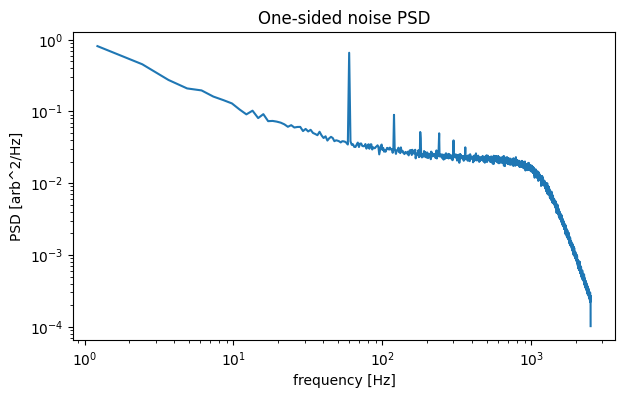

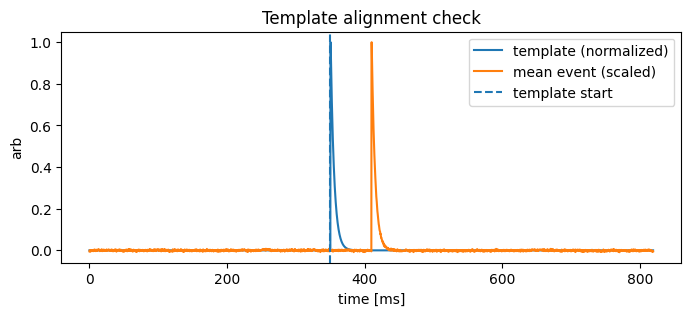

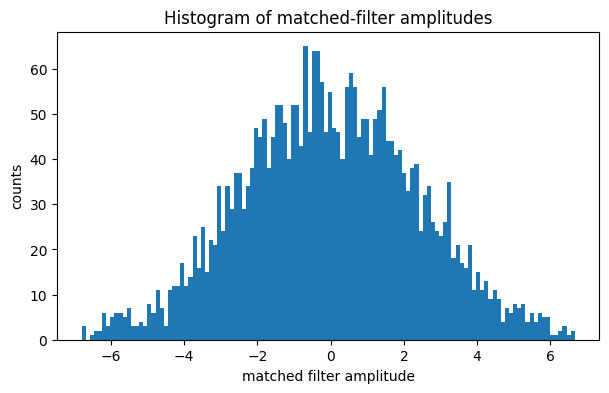

mus: [-0.87269153 -0.39155966  1.224922    2.4389736 ]
sigs: [1.85969094 0.07143445 0.61653424 1.41744406]
areas: [1957.72265015   28.15750833  117.04027212  618.73757056]
flat per bin: 1.49283796465646
flat fraction (est): 0.08985875939800929


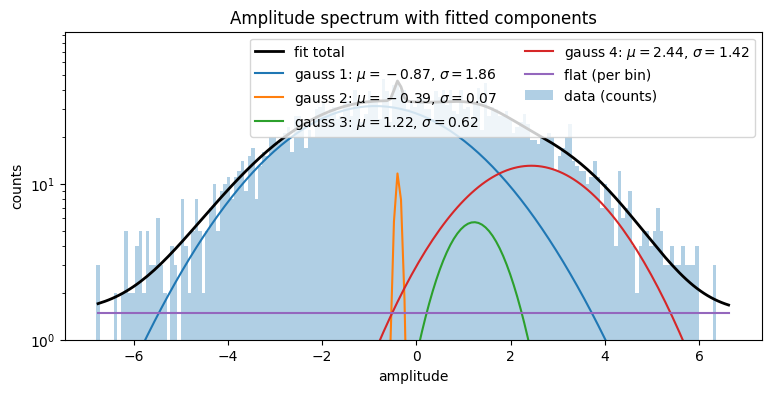

Assigned peaks (sorted):
noise blob: mu = -0.8726915329333877 sigma = 1.8596909357203992
line 1:     mu = -0.39155966099389233 sigma = 0.07143444577992167
line 2:     mu = 1.2249219961302358 sigma = 0.6165342375655888
line 3:     mu = 2.43897359684198 sigma = 1.4174440642715223


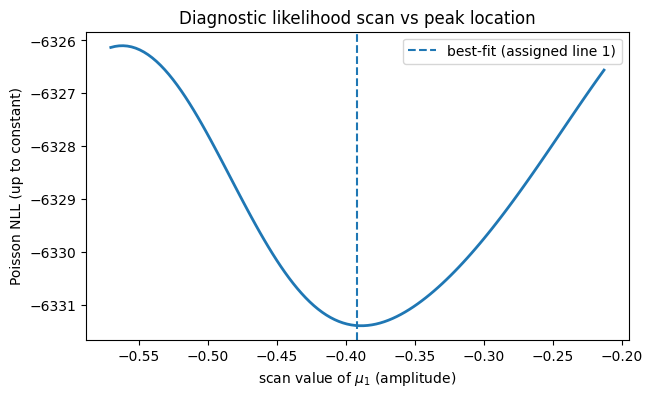

Calibration parameters:
a = 5411.152492452247
b = 256092.66448247508


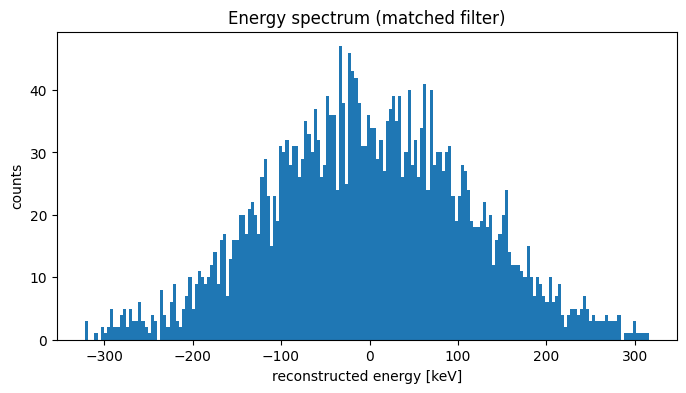

Threshold in amplitude: 8.425763145668608
Threshold in energy [keV]: 399.0753968452261


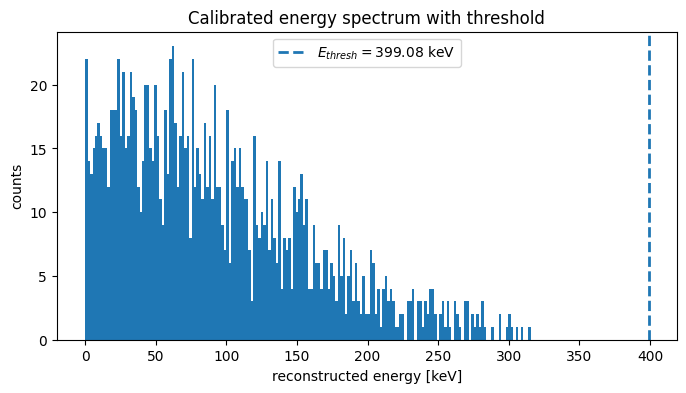

In [ ]:
# PHY 657 PS3 - Problem 3 


import json
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import norm
from numpy.fft import fft, ifft, fftfreq, rfftfreq

# ----------------------------
# 0) Load helper notebook code
# ----------------------------
HELPER_IPYNB = "/Users/hani/Documents/Data/Module3/problem_3_helper.ipynb"

def load_helper_functions(ipynb_path: str, globals_dict: dict):
    """
    Executes only the code cells in the helper notebook that define functions we need.
    This keeps you aligned with your instructor's helper while avoiding their demo cells.
    """
    nb = json.loads(open(ipynb_path, "r").read())
    for cell in nb["cells"]:
        if cell.get("cell_type") != "code":
            continue
        src = "".join(cell.get("source", []))
        # execute only cells that define the helper functions we rely on
        if "def calc_psd" in src or "def foldpsd" in src or "def optimal_filter_amp" in src or "def fit_spectrum_curvefit" in src:
            exec(src, globals_dict)

# Load helper functions into this notebook's namespace
load_helper_functions(HELPER_IPYNB, globals())

print("Loaded helper functions:",
      "calc_psd" in globals(),
      "foldpsd" in globals(),
      "optimal_filter_amp" in globals(),
      "fit_spectrum_curvefit" in globals())

# ----------------------------
# 1) Load data files (.npy)
# ----------------------------
NOISE_FILE  = "/Users/hani/Documents/Data/Module3/noise_traces.npy"
EVENT_FILE  = "/Users/hani/Documents/Data/Module3/event_traces.npy"

noise_traces = np.load(NOISE_FILE)   # shape (300, 4096)
event_traces = np.load(EVENT_FILE)   # shape (3000, 4096)

print("noise_traces:", noise_traces.shape, noise_traces.dtype)
print("event_traces:", event_traces.shape, event_traces.dtype)

# ----------------------------
# 2) Global settings
# ----------------------------
fs = 5e3                    # Hz (matches instructor helper example)
nbins = event_traces.shape[1]
dt = 1.0 / fs
t = np.arange(nbins) * dt

# pre-trigger window for baseline estimation (safe choice)
pre = 500

def subtract_baseline(traces, pre_samples=500):
    base = np.mean(traces[:, :pre_samples], axis=1, keepdims=True)
    return traces - base

noise0 = subtract_baseline(noise_traces, pre)
events0 = subtract_baseline(event_traces, pre)

# ------------------------------------------------------------
# Part I) PSD from noise + matched filter amplitudes
# ------------------------------------------------------------
# PSD J(f) from noise-only dataset (two-sided for filter, one-sided for plotting) :contentReference[oaicite:2]{index=2}
f2, psd2 = calc_psd(noise0, fs=fs, folded_over=False)   # two-sided PSD (length nbins)

# Plot one-sided PSD on log-log plot :contentReference[oaicite:3]{index=3}
f1, psd1 = foldpsd(psd2, fs)

plt.figure(figsize=(7,4))
plt.loglog(f1[1:], psd1[1:])   # skip DC for nicer plot
plt.xlabel("frequency [Hz]")
plt.ylabel("PSD [arb^2/Hz]")
plt.title("One-sided noise PSD")
plt.show()

# Template pulse: s(t) ∝ exp(-t/τ_fall) - exp(-t/τ_rise), max normalized to 1 :contentReference[oaicite:4]{index=4}
tau_rise = 100e-6   # 100 µs
tau_fall = 5e-3     # 5 ms

# pick pulse location from mean event (works well for aligned triggers)
mean_evt = np.mean(events0, axis=0)
i_peak = int(np.argmax(mean_evt))

# choose a start time a bit before the peak so rising edge exists
i0 = max(0, i_peak - 300)

def make_template(nbins, dt, i0, tau_rise, tau_fall):
    tt = np.arange(nbins) * dt
    tr = (np.arange(nbins) - i0) * dt
    s = np.zeros(nbins)
    mask = tr >= 0
    s[mask] = np.exp(-tr[mask]/tau_fall) - np.exp(-tr[mask]/tau_rise)
    # normalize to max=1
    s = s / np.max(s)
    return s

template = make_template(nbins, dt, i0, tau_rise, tau_fall)

plt.figure(figsize=(8,3))
plt.plot(t*1e3, template, label="template (normalized)")
plt.plot(t*1e3, mean_evt/np.max(mean_evt), label="mean event (scaled)")
plt.axvline(i0*dt*1e3, linestyle="--", label="template start")
plt.xlabel("time [ms]")
plt.ylabel("arb")
plt.title("Template alignment check")
plt.legend()
plt.show()

# Matched/optimal filter amplitude estimator :contentReference[oaicite:5]{index=5}
amps_mf = np.empty(events0.shape[0])
sigmas_mf = np.empty(events0.shape[0])

for i in range(events0.shape[0]):
    a, s = optimal_filter_amp(events0[i], template, psd2, fs, coupling="AC")
    amps_mf[i] = a
    sigmas_mf[i] = s

plt.figure(figsize=(7,4))
plt.hist(amps_mf, bins=120, range=(np.percentile(amps_mf, 0.2), np.percentile(amps_mf, 99.8)))
plt.xlabel("matched filter amplitude")
plt.ylabel("counts")
plt.title("Histogram of matched-filter amplitudes")
plt.show()

# ------------------------------------------------------------
# Part II) Fit histogram: 3 lines + noise blob (+ flat background)
# ------------------------------------------------------------
# The PDF says: fit spectrum with Gaussians + flat background and record µi, σi :contentReference[oaicite:6]{index=6}
# We'll use 4 Gaussians (noise blob + 3 lines) and include_flat=True.
fit_res = fit_spectrum_curvefit(
    amps_mf,
    n_lines=4,
    mus_guess=None,        # helper will guess from histogram peaks
    sig_guess=None,
    include_flat=True,
    bins=180,
    range_vals=(np.percentile(amps_mf, 0.2), np.percentile(amps_mf, 99.8)),
    verbose=True
)

centers = fit_res["bin_centers"]
counts  = fit_res["counts"]
bw      = fit_res["bin_edges"][1] - fit_res["bin_edges"][0]

plt.figure(figsize=(9,4))
plt.bar(centers, counts, width=bw, alpha=0.35, label="data (counts)")
plt.plot(centers, fit_res["model_counts"], "k-", lw=2, label="fit total")

for i in range(len(fit_res["mus"])):
    comp = fit_res["areas"][i] * norm.pdf(centers, loc=fit_res["mus"][i], scale=fit_res["sigs"][i]) * bw
    plt.plot(centers, comp, lw=1.5, label=fr"gauss {i+1}: $\mu={fit_res['mus'][i]:.2f}$, $\sigma={fit_res['sigs'][i]:.2f}$")

plt.plot(centers, np.full_like(centers, fit_res["flat_counts_per_bin"]), lw=1.5, label="flat (per bin)")
plt.yscale("log")
plt.ylim(1, max(10, np.max(counts))*2)
plt.xlabel("amplitude")
plt.ylabel("counts")
plt.title("Amplitude spectrum with fitted components")
plt.legend(ncol=2)
plt.show()

# Identify peaks: sort by mean amplitude.
# Usually: smallest is noise-blob, then 25 keV, 65 keV, 100 keV (in increasing amplitude order).
order = np.argsort(fit_res["mus"])
mus_sorted  = fit_res["mus"][order]
sigs_sorted = fit_res["sigs"][order]

mu_noise, sig_noise = mus_sorted[0], sigs_sorted[0]
mu_1, sig_1 = mus_sorted[1], sigs_sorted[1]
mu_2, sig_2 = mus_sorted[2], sigs_sorted[2]
mu_3, sig_3 = mus_sorted[3], sigs_sorted[3]

print("Assigned peaks (sorted):")
print("noise blob: mu =", mu_noise, "sigma =", sig_noise)
print("line 1:     mu =", mu_1,     "sigma =", sig_1)
print("line 2:     mu =", mu_2,     "sigma =", sig_2)
print("line 3:     mu =", mu_3,     "sigma =", sig_3)

# Diagnostic: negative log-likelihood vs mu1 scan (Poisson) :contentReference[oaicite:7]{index=7}
# We keep all parameters fixed except mu_1, and compute NLL = sum(λ - n log λ) up to constants.
def model_counts_with_mu1(mu1_value, popt, n_gauss=4, include_flat=True):
    p = popt.copy()
    # parameters are [area1, mu1, sig1, area2, mu2, sig2, ...]
    # but our "mu_1" is the SECOND smallest peak, not necessarily "gauss1".
    # So we do the scan by rebuilding a new popt where the component that corresponds to mu_1 is shifted.
    # easiest: identify which fitted gaussian has mean closest to mu_1 and shift that one.
    means = []
    ptr = 0
    for g in range(n_gauss):
        means.append(p[ptr+1])
        ptr += 3
    means = np.array(means)
    idx = int(np.argmin(np.abs(means - mu_1)))
    p[idx*3 + 1] = mu1_value

    # use the same internal model form as the helper
    out = np.zeros_like(centers, dtype=float)
    ptr = 0
    for g in range(n_gauss):
        area = p[ptr]; mu = p[ptr+1]; sig = p[ptr+2]
        ptr += 3
        out += area * norm.pdf(centers, loc=mu, scale=max(1e-9, abs(sig))) * bw
    if include_flat:
        out = out + max(0.0, p[ptr])
    return out

def poisson_nll(counts_obs, lam):
    lam_safe = np.clip(lam, 1e-12, None)
    return np.sum(lam_safe - counts_obs * np.log(lam_safe))

mu_scan = np.linspace(mu_1 - 2.5*sig_1, mu_1 + 2.5*sig_1, 120)
nll_scan = np.array([poisson_nll(counts, model_counts_with_mu1(m, fit_res["popt"])) for m in mu_scan])

plt.figure(figsize=(7,4))
plt.plot(mu_scan, nll_scan, lw=2)
plt.axvline(mu_1, linestyle="--", label="best-fit (assigned line 1)")
plt.xlabel(r"scan value of $\mu_1$ (amplitude)")
plt.ylabel("Poisson NLL (up to constant)")
plt.title("Diagnostic likelihood scan vs peak location")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Part III) Energy calibration: saturation model + inverse
# ------------------------------------------------------------

# comment here

# True energies: 25, 65, 100 keV :contentReference[oaicite:8]{index=8}
# Response model: A(E) = a * (1 - exp(-E/b)) (your PDF writes this for Erecon) :contentReference[oaicite:9]{index=9}
E_true = np.array([25.0, 65.0, 100.0])  # keV
A_meas = np.array([mu_1, mu_2, mu_3])

def sat_model(E, a, b):
    return a * (1.0 - np.exp(-E / b))

p0 = (np.max(A_meas)*1.2, 50.0)
popt_cal, pcov_cal = curve_fit(sat_model, E_true, A_meas, p0=p0, bounds=([0.0, 1e-6], [np.inf, np.inf]))
a_cal, b_cal = popt_cal

print("Calibration parameters:")
print("a =", a_cal)
print("b =", b_cal)

# Inverse calibration: E(A) = -b * ln(1 - A/a)
def inv_sat(A, a, b):
    A = np.asarray(A)
    frac = 1.0 - (A / a)
    frac = np.clip(frac, 1e-12, None)
    return -b * np.log(frac)

E_mf = inv_sat(amps_mf, a_cal, b_cal)

plt.figure(figsize=(8,4))
plt.hist(E_mf, bins=180, range=(np.percentile(E_mf, 0.2), np.percentile(E_mf, 99.8)))
plt.xlabel("reconstructed energy [keV]")
plt.ylabel("counts")
plt.title("Energy spectrum (matched filter)")
plt.show()

# ------------------------------------------------------------
# Part IV) Threshold from noise blob: Ethresh = μn + 5 σn
# ------------------------------------------------------------
# threshold definition :contentReference[oaicite:10]{index=10}
A_thresh = mu_noise + 5.0 * sig_noise
E_thresh = inv_sat(A_thresh, a_cal, b_cal)

print("Threshold in amplitude:", A_thresh)
print("Threshold in energy [keV]:", E_thresh)

plt.figure(figsize=(8,4))
plt.hist(E_mf, bins=180, range=(0, np.percentile(E_mf, 99.8)))
plt.axvline(E_thresh, linestyle="--", lw=2, label=fr"$E_{{thresh}}={E_thresh:.2f}$ keV")
plt.xlabel("reconstructed energy [keV]")
plt.ylabel("counts")
plt.title("Calibrated energy spectrum with threshold")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Part V) Detection efficiency via injection into real noise
# ------------------------------------------------------------
# Efficiency definition: ε(E) = N_detected(E) / N_injected(E) :contentReference[oaicite:11]{index=11}

rng = np.random.default_rng(0)

def amplitude_from_true_energy(E, a, b):
    return sat_model(np.asarray(E), a, b)

def inject_and_detect_efficiency(E_grid, n_inject=300):
    """
    For each energy in E_grid:
      pick random noise traces,
      inject template scaled to A_true(E),
      run matched filter + calibration,
      count detected (E_rec > E_thresh)
    """
    eff = np.zeros_like(E_grid, dtype=float)

    for j, E in enumerate(E_grid):
        A_true = amplitude_from_true_energy(E, a_cal, b_cal)

        idx = rng.integers(0, noise0.shape[0], size=n_inject)
        injected = noise0[idx].copy() + A_true * template[None, :]

        # matched filter amplitudes
        A_hat = np.empty(n_inject)
        for i in range(n_inject):
            A_hat[i], _ = optimal_filter_amp(injected[i], template, psd2, fs, coupling="AC")

        E_hat = inv_sat(A_hat, a_cal, b_cal)
        eff[j] = np.mean(E_hat > E_thresh)

    return eff

E_grid = np.linspace(0, 120, 25)
eff_mf = inject_and_detect_efficiency(E_grid, n_inject=250)

plt.figure(figsize=(7,4))
plt.plot(E_grid, eff_mf, marker="o")
plt.xlabel("true injected energy [keV]")
plt.ylabel("efficiency")
plt.ylim(-0.05, 1.05)
plt.title("Detection efficiency (matched filter)")
plt.show()

# ------------------------------------------------------------
# Part VI) Alternative estimators: peak + integral
# Repeat calibration + threshold + efficiency for each
# ------------------------------------------------------------
# The PDF asks to redo analysis for peak and integral estimators :contentReference[oaicite:12]{index=12}

# Define a pulse window (integral estimator) relative to template start i0
win_start = i0
win_end   = min(nbins, i0 + 1800)   # ~0.36 s window at 5 kHz; adjust if you want tighter
# A tighter window (e.g., i0 to i0+800) is also fine; consistency matters most.

def peak_estimator(traces):
    return np.max(traces, axis=1)

def integral_estimator(traces, i1, i2):
    return np.sum(traces[:, i1:i2], axis=1)

def full_chain_for_estimator(raw_events, raw_noise, A_estimator_func, estimator_name="est"):
    """
    For a chosen estimator that outputs "amplitude-like" numbers:
      1) get A for events
      2) fit spectrum (4 gauss + flat) -> get mu_noise, mu_lines
      3) calibrate using saturation model
      4) threshold
      5) efficiency by injection (using the same estimator)
    """
    A_events = A_estimator_func(raw_events)

    # fit spectrum
    res = fit_spectrum_curvefit(
        A_events,
        n_lines=4,
        include_flat=True,
        bins=180,
        range_vals=(np.percentile(A_events, 0.2), np.percentile(A_events, 99.8)),
        verbose=False
    )

    ord2 = np.argsort(res["mus"])
    mus2 = res["mus"][ord2]
    sig2 = res["sigs"][ord2]

    muN, sigN = mus2[0], sig2[0]
    muL = mus2[1:4]

    # calibration
    popt, _ = curve_fit(sat_model, E_true, muL, p0=(np.max(muL)*1.2, 50.0), bounds=([0.0, 1e-6], [np.inf, np.inf]))
    aE, bE = popt

    # threshold
    A_th = muN + 5.0 * sigN
    E_th = inv_sat(A_th, aE, bE)

    # efficiency injection
    def eff_for_grid(E_grid, n_inject=250):
        out = np.zeros_like(E_grid, dtype=float)
        for j, E in enumerate(E_grid):
            A_true = sat_model(E, aE, bE)
            idx = rng.integers(0, raw_noise.shape[0], size=n_inject)
            injected = raw_noise[idx].copy() + A_true * template[None, :]
            A_hat = A_estimator_func(injected)
            E_hat = inv_sat(A_hat, aE, bE)
            out[j] = np.mean(E_hat > E_th)
        return out

    return {
        "name": estimator_name,
        "A_events": A_events,
        "fit": res,
        "a": aE,
        "b": bE,
        "A_thresh": A_th,
        "E_thresh": E_th,
        "eff": eff_for_grid(E_grid)
    }

# Run for peak
res_peak = full_chain_for_estimator(
    events0, noise0,
    A_estimator_func=peak_estimator,
    estimator_name="Peak"
)

# Run for integral
res_int = full_chain_for_estimator(
    events0, noise0,
    A_estimator_func=lambda tr: integral_estimator(tr, win_start, win_end),
    estimator_name="Integral"
)

# Overlay efficiency curves
plt.figure(figsize=(7,4))
plt.plot(E_grid, eff_mf, marker="o", label="Matched Filter")
plt.plot(E_grid, res_peak["eff"], marker="o", label="Peak")
plt.plot(E_grid, res_int["eff"], marker="o", label="Integral")
plt.xlabel("true injected energy [keV]")
plt.ylabel("efficiency")
plt.ylim(-0.05, 1.05)
plt.title("Efficiency comparison")
plt.legend()
plt.show()

# Simple comparison table printout (threshold energies)
print("\nThreshold energies [keV]:")
print("Matched Filter:", E_thresh)
print("Peak:",          res_peak["E_thresh"])
print("Integral:",      res_int["E_thresh"])

## Discussion: Saturation Model vs Polynomial/Spline Fit (Energy Calibration)

In Part III, the detector response was modeled using the saturation function

$
A(E) = a \left(1 - e^{-E/b} \right),
$

with inverse calibration

$
E(A) = -b \ln \left(1 - \frac{A}{a} \right).
$

### Benefits of the Saturation Model

1. **Physically motivated**  
   The exponential form reflects real detector behavior: response is approximately linear at low energy and gradually saturates at high energy.

2. **Monotonic and well-behaved**  
   The model guarantees a smooth, increasing relationship between amplitude and energy, avoiding unphysical oscillations.

3. **Stable inversion**  
   The analytic inverse $E(A)$ allows direct and stable energy reconstruction.

4. **Better extrapolation**  
   Outside calibration points (25, 65, 100 keV), the model remains physically reasonable.  
   A polynomial or spline may diverge or curve unrealistically.

5. **Fewer parameters**  
   Only two parameters $(a, b)$ are required, reducing overfitting risk.

---

### Limitations of Polynomial or Spline Fits

- They are purely empirical.
- They may oscillate between calibration points.
- High-order polynomials can produce unphysical curvature.
- Inversion may not be analytic or stable.

---

### Conclusion

The saturation model is preferred because it encodes detector physics, ensures monotonicity, allows analytic inversion, and provides stable extrapolation beyond calibration energies.

## Discussion: Matched Filter vs Peak and Integral Estimators

### Why the Matched Filter Performs Differently

The matched filter is derived from maximum-likelihood estimation assuming Gaussian noise.  
For data
$
d(t) = A\,s(t) + n(t),
$

The optimal amplitude estimator is

$
\hat{A} \propto \int \frac{\tilde d(f)\,\tilde s^*(f)}{J(f)} \, df,
$

where $J(f)$ is the noise power spectral density.

This estimator:

- Correlates the data with the known signal shape $s(t)$.
- Weights frequencies by $1/J(f)$.
- Maximizes signal-to-noise ratio.

In contrast:

- **Peak estimator:** $A_{\text{peak}} = \max d(t)$  
  Sensitive to high-frequency noise.
- **Integral estimator:** $A_{\text{int}} = \int d(t)\,dt$  
  Integrates both signal and noise uniformly.

Neither accounts for the noise spectrum or the full pulse shape.

---

### Effect of Colored Noise

If noise is white:

$
J(f) = \text{constant},
$

The matched filter reduces to simple correlation.

If noise is **colored** ($J(f)$ varies with frequency):

- The matched filter suppresses noisy frequency bands.
- It emphasizes frequency regions with higher signal-to-noise ratio.
- It effectively "whitens" the data.

Peak and integral estimators treat all frequencies equally and are therefore suboptimal in colored noise.

---

### Impact on Detection Efficiency

Detection threshold is set by

$
E_{\text{thresh}} = \mu_n + 5\sigma_n.
$

Because the matched filter has smaller variance $\sigma_n$:

- Threshold is lower.
- Efficiency rises faster with energy.
- Low-energy detection improves.

Peak estimator typically has the largest variance and worst efficiency.  
Integral estimator performs moderately.